# 02_eda.ipynb

**Project:** Hydraulic Condition Monitoring Dashboard  
**Stage:** Exploratory Data Analysis (EDA)

---

### 🎯 Purpose
This notebook performs the initial exploratory analysis of the canonical dataset prepared in  
[`01_load_data.ipynb`](01_load_data.ipynb).

It:
- Loads the **frozen artifacts** (`.parquet` and `features_index.csv`)
- Examines structure, missing values, and summary statistics
- Analyzes label distributions and relationships between sensor groups
- Compares **stable vs unstable cycles**
- Performs a light **temporal drift check**
- Saves clean visuals to `/images/eda/`

---

### 📦 Input Artifacts
| File | Description |
|------|------------|
| `data/processed/X_features.parquet` | Canonical features per cycle |
| `data/processed/y_labels.parquet`   | Aligned condition labels (5 targets) |
| `data/metadata/features_index.csv`  | Dictionary of sensors, groups, and features |

> ✅ No raw `.txt` files or `data_io.py` imports are used here.


In [1]:
# === Imports & setup ===
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
BASE_DIR = Path.cwd().parents[0] if (Path.cwd().name == "notebooks") else Path.cwd()
DATA_DIR = BASE_DIR / "data"
PROC_DIR = DATA_DIR / "processed"
META_DIR = DATA_DIR / "metadata"
IMG_DIR = BASE_DIR / "images" / "eda"

# Ensure image directory exists
IMG_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("default")
sns.set(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


## 1. Load dataset artifacts

We now load the cleaned, aligned feature and label artifacts produced by `01_load_data.ipynb`.  
This notebook **never touches raw .txt files** and does not depend on utility modules:

- Features are read from `/data/processed`
- Labels from `/data/processed`
- Metadata (feature dictionary) from `/data/metadata`

This design makes EDA **re-runnable** from a fresh clone as long as the artifacts exist.


In [2]:
X = pd.read_parquet(PROC_DIR / "X_features.parquet")
y = pd.read_parquet(PROC_DIR / "y_labels.parquet")
features_index = pd.read_csv(META_DIR / "features_index.csv")

print("Shapes:")
print("X:", X.shape)
print("y:", y.shape)
print("features_index:", features_index.shape)

assert len(X) == len(y), f"Row mismatch: X={len(X)}, y={len(y)}"

display(X.head(3))
display(y.head(3))
display(features_index.head(5))


Shapes:
X: (2205, 43680)
y: (2205, 5)
features_index: (43680, 3)


,CE_t1,CE_t2,CE_t3,CE_t4,CE_t5,CE_t6,CE_t7,CE_t8,CE_t9,CE_t10,CE_t11,CE_t12,CE_t13,CE_t14,CE_t15,CE_t16,CE_t17,CE_t18,CE_t19,CE_t20,CE_t21,CE_t22,CE_t23,CE_t24,CE_t25,...,VS1_t36,VS1_t37,VS1_t38,VS1_t39,VS1_t40,VS1_t41,VS1_t42,VS1_t43,VS1_t44,VS1_t45,VS1_t46,VS1_t47,VS1_t48,VS1_t49,VS1_t50,VS1_t51,VS1_t52,VS1_t53,VS1_t54,VS1_t55,VS1_t56,VS1_t57,VS1_t58,VS1_t59,VS1_t60
0,47.202,47.273,47.250,47.332,47.213,47.372,47.273,47.438,46.691,46.599,46.623,46.653,46.136,46.127,45.948,45.935,45.726,45.139,44.978,44.937,44.269,44.079,43.741,43.375,42.847,...,0.600,0.604,0.624,0.616,0.593,0.607,0.592,0.585,0.572,0.577,0.576,0.568,0.563,0.559,0.557,0.554,0.552,0.545,0.553,0.553,0.539,0.544,0.545,0.535,0.543
1,29.208,28.822,28.805,28.922,28.591,28.643,28.216,27.812,27.514,27.481,27.631,27.464,27.258,27.424,26.955,27.023,26.834,27.073,27.260,27.236,26.720,26.824,26.757,26.311,26.431,...,0.582,0.578,0.573,0.570,0.570,0.568,0.567,0.555,0.557,0.553,0.556,0.547,0.552,0.588,0.567,0.555,0.547,0.548,0.544,0.536,0.542,0.540,0.533,0.531,0.534
2,23.554,23.521,23.527,23.008,23.042,23.052,22.658,22.952,22.908,22.359,22.287,22.213,22.562,22.525,22.725,22.630,22.745,22.643,22.997,22.997,22.903,22.761,22.701,22.818,22.785,...,0.599,0.588,0.590,0.583,0.564,0.560,0.559,0.561,0.550,0.560,0.554,0.561,0.566,0.558,0.547,0.543,0.544,0.543,0.554,0.544,0.544,0.545,0.544,0.530,0.534


,cooler_condition,valve_condition,internal_pump_leakage,hydraulic_accumulator,stable_flag
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1


,column,sensor,group
0,CE_t1,CE,cooler
1,CE_t2,CE,cooler
2,CE_t3,CE,cooler
3,CE_t4,CE,cooler
4,CE_t5,CE,cooler


`feature_index.csv` schema (frozen contract):
- `column` : exact column name in `X`
- `sensor` : base sensor code (e.g., PS1, TS1)
- `stat`   : aggregation or transformation (mean, std, min, max, etc.)
- `group`  : functional group (pressure, temperature, vibration, flow, cooler, electrical, other)

All downstream notebooks assume this schema.


## 2. Basic dataset overview

We begin with high-level checks:
- Data types and memory footprint
- Missing values per column
- Global min / max and simple sanity checks on ranges


In [3]:
print("=== Feature DataFrame Info ===")
X.info(memory_usage="deep")

print("\n=== Label Summary ===")
print(y.describe(include="all"))

# Column-wise missing fraction (used for artifacts)
missing = X.isna().mean().sort_values(ascending=False)
print("\nTop missing columns (by missing fraction):")
display(missing.head(10))

# Global sanity checks
total_missing = X.isna().sum().sum()
any_negative = (X < 0).any().any()
global_min = X.min().min()
global_max = X.max().max()

print(f"\nTotal missing values in X: {total_missing}")
print(f"Any negative values in X: {any_negative}")
print(f"Global min in X: {global_min:.3f}")
print(f"Global max in X: {global_max:.3f}")

# Save missing summary for reproducibility
missing.to_csv(META_DIR / "eda_missing_summary.csv", header=["missing_fraction"])


=== Feature DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Columns: 43680 entries, CE_t1 to VS1_t60
dtypes: float64(43646), int64(34)
memory usage: 734.8 MB

=== Label Summary ===
       cooler_condition  valve_condition  internal_pump_leakage  hydraulic_accumulator  stable_flag
count       2205.000000      2205.000000            2205.000000            2205.000000  2205.000000
mean          41.240816        90.693878               0.669388             107.199546     0.342857
std           42.383143        10.681802               0.817233              16.435848     0.474772
min            3.000000        73.000000               0.000000              90.000000     0.000000
25%            3.000000        80.000000               0.000000              90.000000     0.000000
50%           20.000000       100.000000               0.000000             100.000000     0.000000
75%          100.000000       100.000000               1.000000           

VS1_t21    0.0
VS1_t22    0.0
VS1_t23    0.0
VS1_t24    0.0
VS1_t25    0.0
VS1_t26    0.0
VS1_t27    0.0
VS1_t28    0.0
VS1_t13    0.0
VS1_t14    0.0
dtype: float64


Total missing values in X: 0
Any negative values in X: False
Global min in X: 0.000
Global max in X: 2995.200


### Data completeness and physical ranges

- **No missing values** were found across all features (0 NaNs per column), so no imputation is required at this stage.
- All sensor features are **non-negative**, which is consistent with physical quantities such as pressures, flows,
  temperatures, and power in the hydraulic system.


## 2.1 Target distributions for all labels

We examine the distribution of each target in `y_labels.parquet` to understand
class balance and guide stratified splits and evaluation metrics.


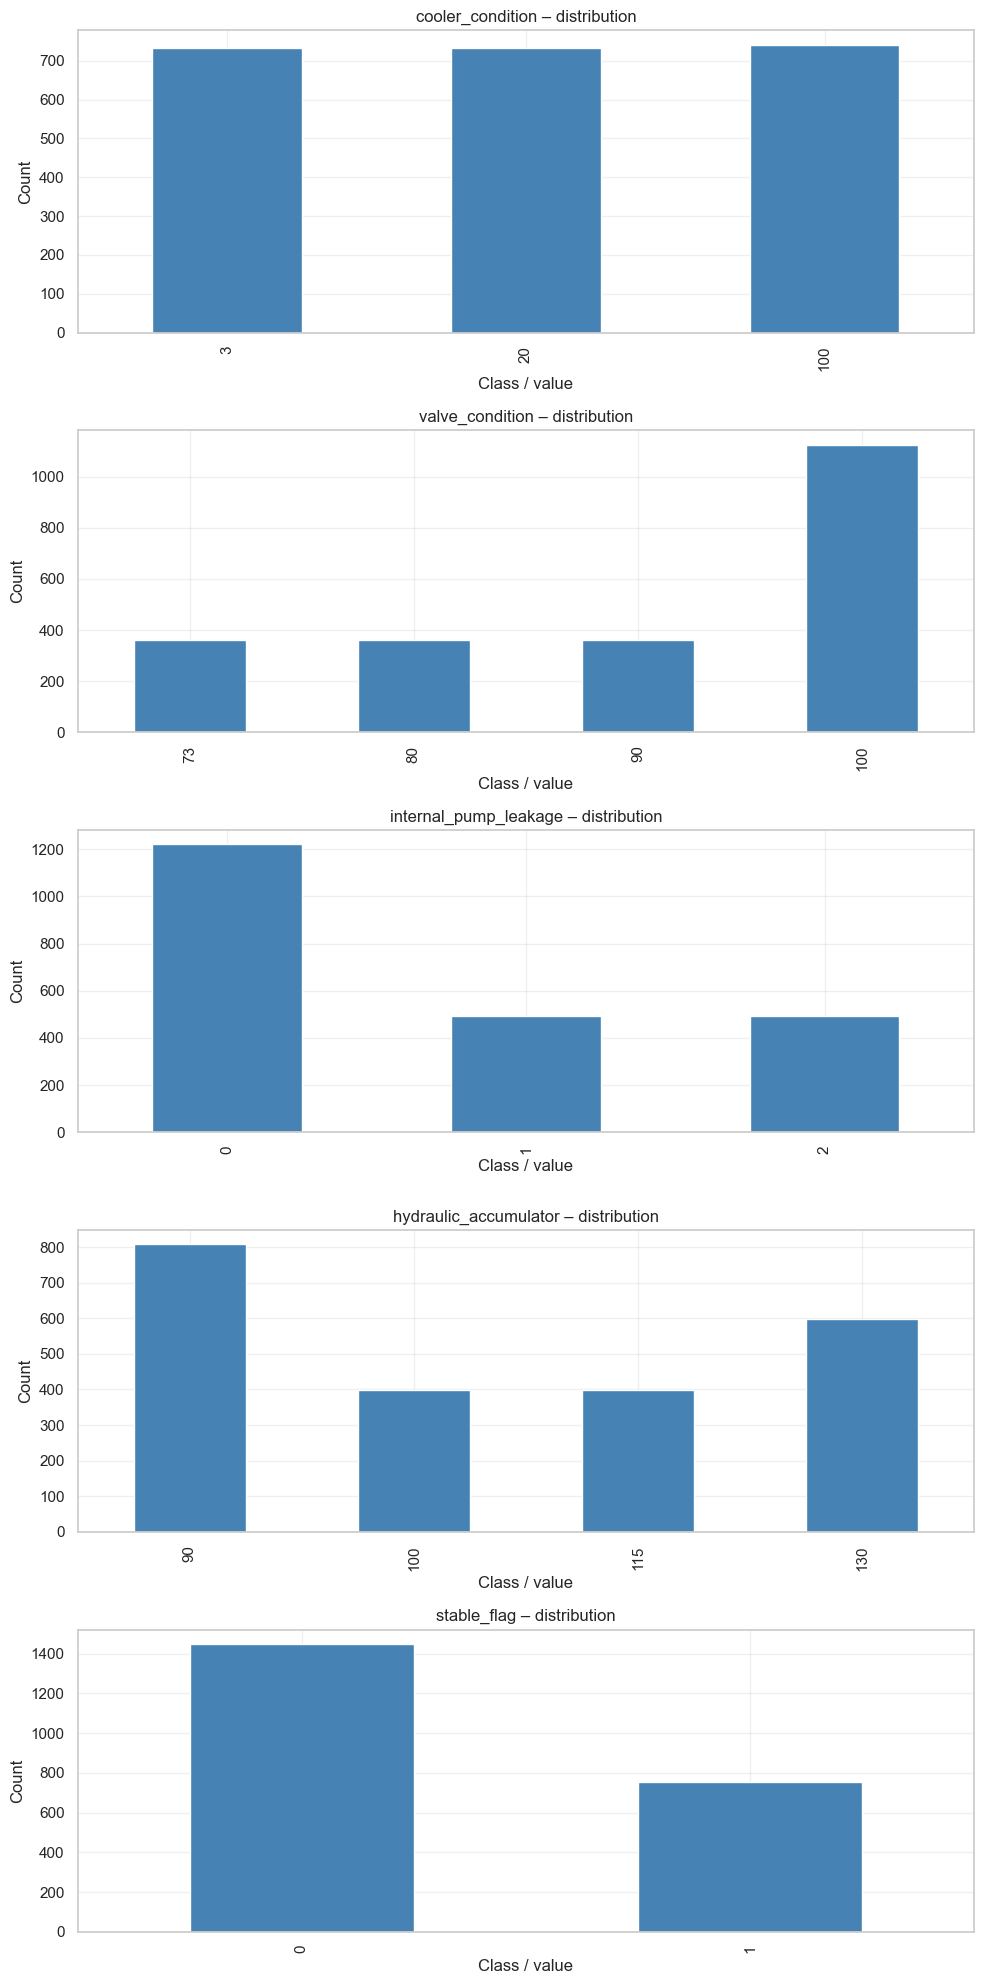

In [4]:
# === Target distributions for all label columns in y ===
if isinstance(y, pd.DataFrame):
    n_targets = y.shape[1]
    fig, axes = plt.subplots(n_targets, 1, figsize=(10, 4 * n_targets))

    if n_targets == 1:
        axes = [axes]

    for ax, col in zip(axes, y.columns):
        y[col].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
        ax.set_title(f"{col} – distribution")
        ax.set_xlabel("Class / value")
        ax.set_ylabel("Count")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(IMG_DIR / "label_distributions_multi.png", dpi=150)
    plt.show()
else:
    plt.figure(figsize=(6, 4))
    y.value_counts().plot(kind="bar", color="steelblue")
    plt.title("Label Distribution")
    plt.xlabel("Class / State")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(IMG_DIR / "label_distribution.png", dpi=150)
    plt.show()


### 2.2 Class imbalance summary and metrics

To go beyond visual bar charts, we compute a compact table with:

- absolute counts per class,
- relative class frequency per target,
- majority / minority class ratio per target.

These tables are saved as `data/metadata/target_distributions.csv` and
`data/metadata/target_imbalance_summary.csv` and will be used to:

- choose **F1-score / balanced metrics** for evaluation,
- configure **stratified train/test splits**,
- decide whether advanced techniques (class weights, resampling) are needed.


In [5]:
# === Class imbalance tables for all targets ===
dist_rows = []

if isinstance(y, pd.DataFrame):
    targets = y.columns
    y_df = y.copy()
else:
    targets = ["target"]
    y_df = pd.DataFrame({"target": y})

for col in targets:
    vc = y_df[col].value_counts().sort_index()
    total = vc.sum()
    if total == 0:
        continue

    majority = vc.max()
    minority = vc.min()
    majority_to_minority = majority / max(minority, 1)

    for cls, count in vc.items():
        dist_rows.append({
            "target": col,
            "class": cls,
            "count": int(count),
            "ratio": float(count / total),
            "majority_to_minority_ratio": float(majority_to_minority),
        })

target_dist = pd.DataFrame(dist_rows).sort_values(["target", "class"])
print("=== Per-class distribution per target ===")
display(target_dist.head(20))

# Aggregate per-target imbalance summary
imbalance_summary = (
    target_dist
    .groupby("target")
    .agg(
        n_classes=("class", "nunique"),
        majority_class_ratio=("ratio", "max"),
        minority_class_ratio=("ratio", "min"),
        majority_to_minority=("majority_to_minority_ratio", "max"),
    )
    .reset_index()
)

print("=== Imbalance summary per target ===")
display(imbalance_summary)

# Save artifacts
target_dist.to_csv(META_DIR / "target_distributions.csv", index=False)
imbalance_summary.to_csv(META_DIR / "target_imbalance_summary.csv", index=False)


=== Per-class distribution per target ===


,target,class,count,ratio,majority_to_minority_ratio
0,cooler_condition,3,732,0.331973,1.012295
1,cooler_condition,20,732,0.331973,1.012295
2,cooler_condition,100,741,0.336054,1.012295
10,hydraulic_accumulator,90,808,0.366440,2.025063
11,hydraulic_accumulator,100,399,0.180952,2.025063
12,hydraulic_accumulator,115,399,0.180952,2.025063
13,hydraulic_accumulator,130,599,0.271655,2.025063
7,internal_pump_leakage,0,1221,0.553741,2.481707
8,internal_pump_leakage,1,492,0.223129,2.481707
9,internal_pump_leakage,2,492,0.223129,2.481707


=== Imbalance summary per target ===


,target,n_classes,majority_class_ratio,minority_class_ratio,majority_to_minority
0,cooler_condition,3,0.336054,0.331973,1.012295
1,hydraulic_accumulator,4,0.366440,0.180952,2.025063
2,internal_pump_leakage,3,0.553741,0.223129,2.481707
3,stable_flag,2,0.657143,0.342857,1.916667
4,valve_condition,4,0.510204,0.163265,3.125000


## 3. Descriptive statistics

We compute basic descriptive statistics for each feature (mean, std, min, max, quartiles)
and save them as a metadata artifact.


In [6]:
desc = X.describe().T
display(desc.head(10))

# Save for optional inspection
desc.to_csv(META_DIR / "eda_summary_stats.csv", index=True)


,count,mean,std,min,25%,50%,75%,max
CE_t1,2205.0,31.325613,11.532175,17.356,20.165,27.334,46.651,48.136
CE_t2,2205.0,31.364606,11.512519,17.552,20.260,27.397,46.675,48.057
CE_t3,2205.0,31.395767,11.504075,17.440,20.333,27.446,46.690,48.124
CE_t4,2205.0,31.402451,11.504153,17.416,20.387,27.455,46.686,48.112
CE_t5,2205.0,31.395373,11.521065,17.392,20.367,27.424,46.693,48.159
CE_t6,2205.0,31.371016,11.539150,17.404,20.328,27.384,46.686,48.253
CE_t7,2205.0,31.351265,11.566626,17.456,20.240,27.356,46.711,48.158
CE_t8,2205.0,31.339065,11.579167,17.396,20.149,27.351,46.698,48.219
CE_t9,2205.0,31.307852,11.571700,17.506,20.113,27.351,46.678,48.146
CE_t10,2205.0,31.238561,11.538494,17.364,20.071,27.313,46.544,48.040


In [7]:
# Identify constant and sparse-spike features for later use in feature engineering
numeric_cols = X.select_dtypes(include=[np.number])
summary_stats = numeric_cols.describe().T

# Constant features: zero variance
constant_mask = summary_stats["std"].fillna(0) == 0
constant_features = summary_stats[constant_mask]

# Sparse spike features: 25% = 50% = 75% = 0, max > 0
sparse_mask = (
    (summary_stats["25%"] == 0) &
    (summary_stats["50%"] == 0) &
    (summary_stats["75%"] == 0) &
    (summary_stats["max"] > 0)
)
sparse_features = summary_stats[sparse_mask]
print("Number of constant features:", constant_mask.sum())
print("Number of sparse spike features:", sparse_mask.sum())

display(constant_features.head())
display(sparse_features.head())


Number of constant features: 34
Number of sparse spike features: 1681


,count,mean,std,min,25%,50%,75%,max
PS3_t9,2205.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PS3_t10,2205.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PS3_t11,2205.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PS3_t12,2205.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PS3_t13,2205.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,count,mean,std,min,25%,50%,75%,max
PS2_t156,2205.0,0.016833,0.037665,0.0,0.0,0.0,0.0,0.250
PS2_t157,2205.0,0.016342,0.036937,0.0,0.0,0.0,0.0,0.242
PS2_t158,2205.0,0.015876,0.036771,0.0,0.0,0.0,0.0,0.250
PS2_t159,2205.0,0.015715,0.036109,0.0,0.0,0.0,0.0,0.234
PS2_t160,2205.0,0.014930,0.034219,0.0,0.0,0.0,0.0,0.211


### Constant and sparse spike features

- We identified **34 constant (zero-variance) features** that carry no information and will be dropped during feature engineering.
- About **1.7k sparse “spike-driven” features** have 25%, 50% and 75% quantiles equal to zero but a strictly positive maximum.  
  This pattern is consistent with **rare physical bursts** (pressure or flow peaks) rather than measurement noise.
- These sparse spike features are **kept** and treated as physically meaningful events.  
  In later notebooks we will:
  - avoid naive “outlier removal” on them,
  - apply **robust scaling / transformations** where needed instead of clipping them away.


## 4. Group-level analysis

Using `features_index.csv`, we aggregate features by functional group  
(e.g., pressure, temperature, vibration, flow, cooler, electrical, other) to understand
typical ranges and variability across subsystems.


In [8]:
group_col = "group"
feature_col = "column"

if group_col not in features_index.columns or feature_col not in features_index.columns:
    raise ValueError("features_index must contain 'group' and 'column' columns")

# Map each feature to a group
group_map = (
    features_index[[feature_col, group_col]]
    .dropna()
    .set_index(feature_col)[group_col]
    .to_dict()
)

# Keep only valid columns that also exist in X
valid_cols = {col: group_map[col] for col in X.columns if col in group_map}

if not valid_cols:
    print("⚠️ No overlapping columns between X and features_index.")
else:
    # Build a DataFrame with group labels per column
    group_labels = pd.Series(valid_cols, name="group")
    group_labels.index.name = "column"
    display(group_labels.value_counts())

    # Aggregate basic statistics by group
    mean_by_group = X[valid_cols.keys()].T.groupby(group_labels).mean().T
    std_by_group  = X[valid_cols.keys()].T.groupby(group_labels).std().T


    display(mean_by_group.describe().T)
    display(std_by_group.describe().T)


group
pressure       36000
electrical      6060
flow            1200
temperature      240
cooler           120
vibration         60
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
cooler,2205.0,16.553738,5.923281,9.395650,10.814275,14.570033,24.415850,25.046100
electrical,2205.0,2471.348596,73.045522,2338.961825,2419.336982,2456.922782,2523.547498,2713.686897
flow,2205.0,7.924001,0.666114,5.485836,7.897868,8.115461,8.320728,8.559207
pressure,2205.0,48.743566,1.791788,46.412923,47.470699,47.775405,50.238152,55.052951
temperature,2205.0,46.047080,7.734123,36.205337,37.120467,45.517671,54.452125,57.995350
vibration,2205.0,0.613315,0.060260,0.524367,0.555100,0.610183,0.649850,0.839067


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
cooler,2205.0,14.809358,5.675572,8.196380,9.313430,12.877868,22.354813,22.953769
electrical,2205.0,315.757813,22.583018,302.224991,306.911782,308.475001,310.136789,388.204926
flow,2205.0,2.768619,0.374635,2.398273,2.577451,2.660155,2.776085,4.010824
pressure,2205.0,66.046553,2.674347,64.033118,64.864876,65.176576,65.504524,77.235950
temperature,2205.0,3.545394,0.329065,2.512111,3.349328,3.468478,3.916143,5.033061
vibration,2205.0,0.042999,0.032313,0.012673,0.026018,0.032527,0.048122,0.465159


### Sensor group structure and scale

- Each functional group (pressure, temperature, vibration, flow, cooler, electrical) contains multiple derived features.
- Group-wise means and standard deviations confirm that some groups (e.g., pressure sensors) operate on higher numeric
  ranges than others (e.g., temperature or electrical power), which will influence scaling strategies.


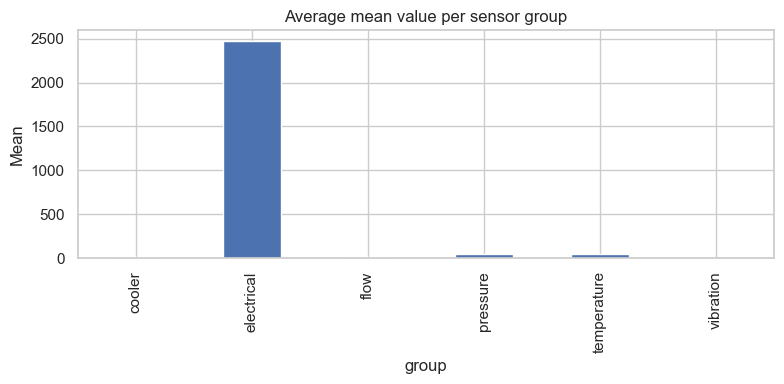

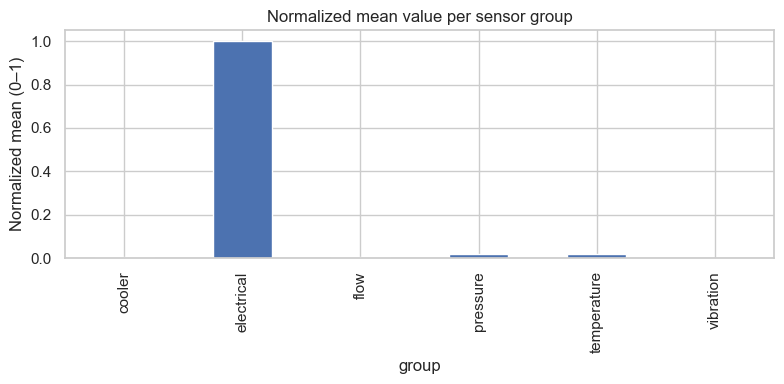

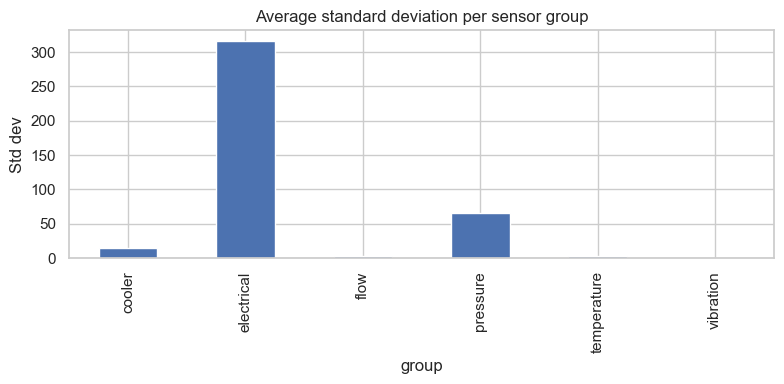

In [9]:
if not valid_cols:
    pass
else:
    # Visualize mean and std per group (for a random sample of cycles)
    mean_per_group = mean_by_group.mean(axis=0)
    std_per_group = std_by_group.mean(axis=0)

    plt.figure(figsize=(8, 4))
    mean_per_group.plot(kind="bar")
    plt.title("Average mean value per sensor group")
    plt.ylabel("Mean")
    plt.tight_layout()
    plt.savefig(IMG_DIR / "mean_values_by_group.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 4))
    (mean_per_group / mean_per_group.max()).plot(kind="bar")
    plt.title("Normalized mean value per sensor group")
    plt.ylabel("Normalized mean (0–1)")
    plt.tight_layout()
    plt.savefig(IMG_DIR / "mean_values_by_group_normalized.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 4))
    std_per_group.plot(kind="bar")
    plt.title("Average standard deviation per sensor group")
    plt.ylabel("Std dev")
    plt.tight_layout()
    plt.savefig(IMG_DIR / "std_values_by_group.png", dpi=150)
    plt.show()


## 5. Correlation and relationships

We now examine how sensors relate to each other, both at the feature level
and the group level.


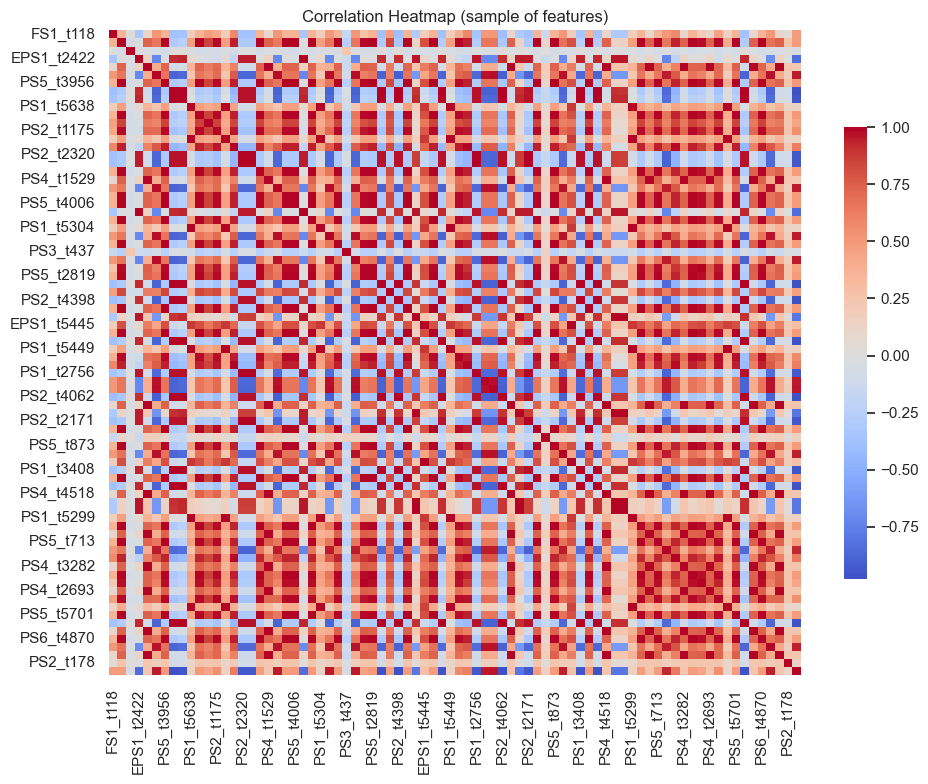

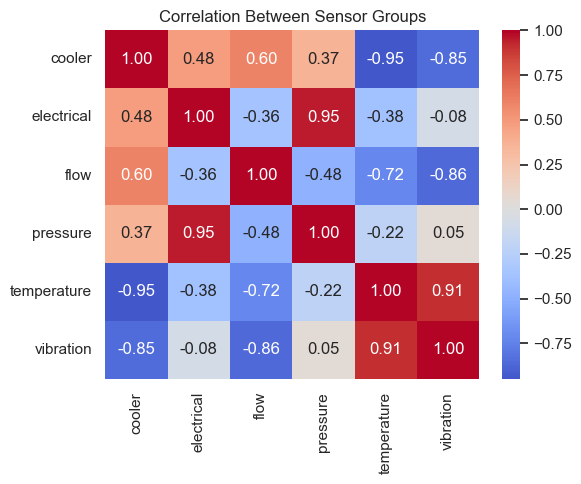

In [10]:
# --- helper: load group mapping from features_index ---
col_to_group = (
    features_index
    .set_index("column")["group"]
    .to_dict()
)

# 1) SAMPLE-BASED CORRELATION (e.g. 80 columns)
# -------------------------------------------------
N_SAMPLE_FEATURES = 80  # you can lower this if still heavy

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# choose only columns that exist in numeric_cols (to avoid weird object cols)
sample_cols = pd.Series(numeric_cols).sample(
    min(N_SAMPLE_FEATURES, len(numeric_cols)),
    random_state=42
).tolist()

corr_sample = X[sample_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_sample,
    cmap="coolwarm",
    center=0,
    cbar_kws={"shrink": 0.7},
)
plt.title("Correlation Heatmap (sample of features)")
plt.tight_layout()
plt.savefig(IMG_DIR / "correlation_heatmap_sample.png", dpi=150)
plt.show()

# 2) GROUP-LEVEL CORRELATION
# -------------------------------------------------
# --- FIX for groupby(axis=1) deprecation ---
grouped_means = X.T.groupby(col_to_group).mean().T
corr_group = grouped_means.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_group,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Between Sensor Groups")
plt.tight_layout()
plt.savefig(IMG_DIR / "correlation_heatmap_groups.png", dpi=150)
plt.show()

display(X_grouped.head()) if 'X_grouped' in globals() else None


## 6. Sample pairwise plots

For a small random subset of features, we generate pairplots to visually inspect
non-linear relationships and potential clusters.


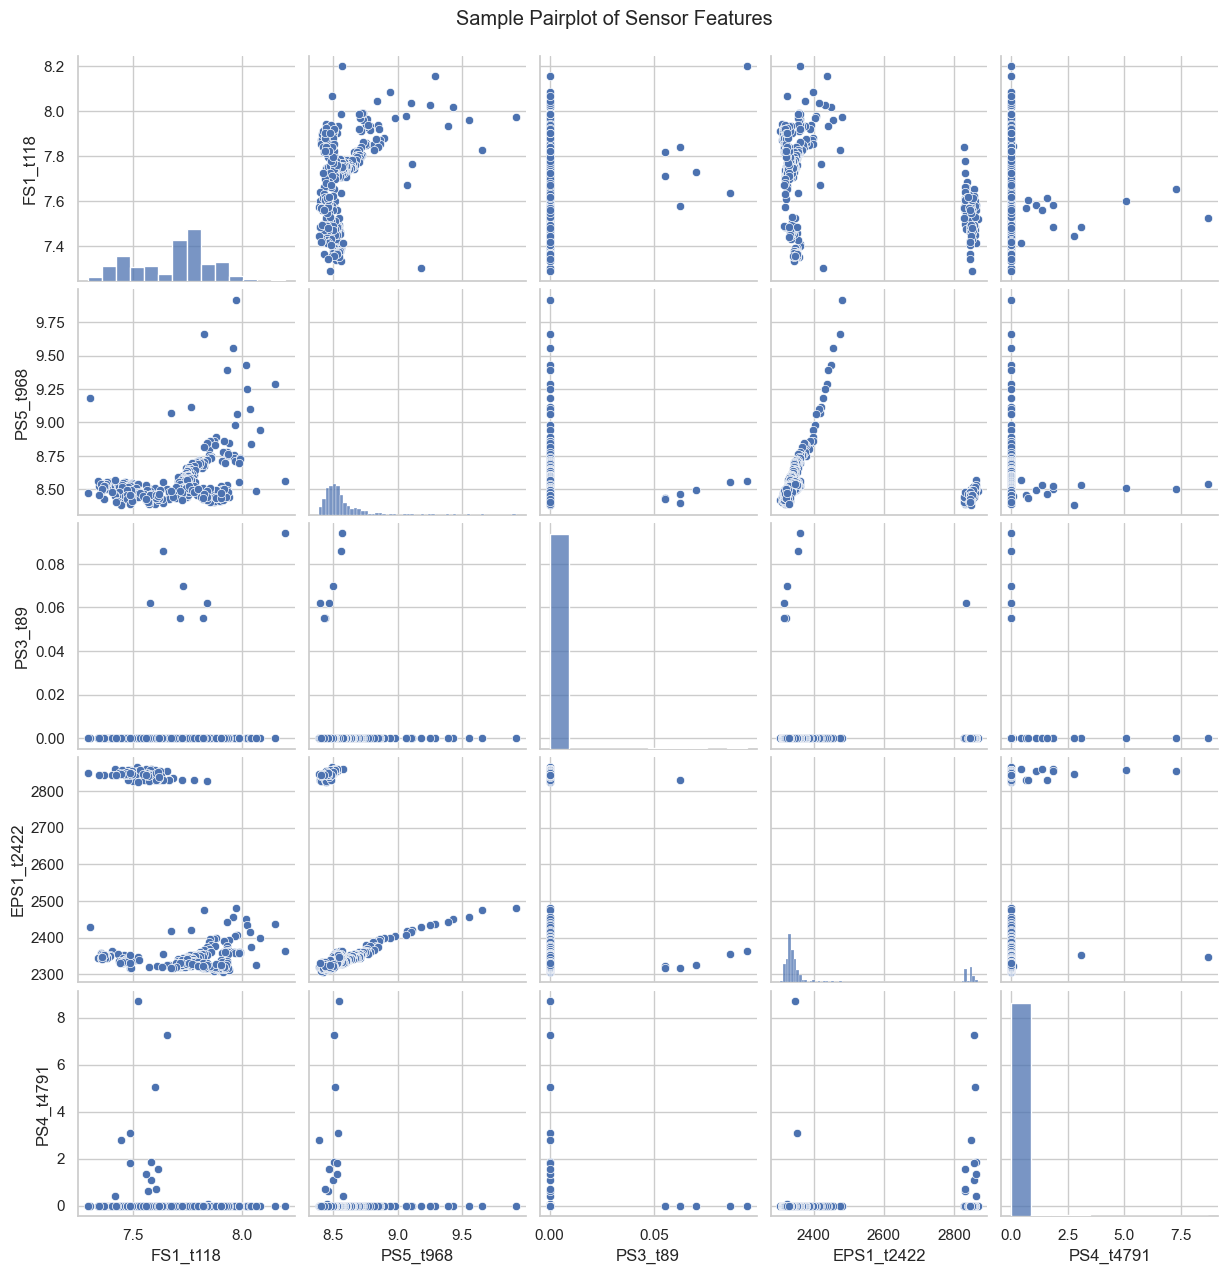

In [11]:
SAMPLE_FOR_PAIRPLOT = 5
pair_cols = pd.Series(X.select_dtypes(include=[np.number]).columns).sample(
    min(SAMPLE_FOR_PAIRPLOT, X.shape[1]),
    random_state=42,
).tolist()

if pair_cols:
    sns.pairplot(X[pair_cols].iloc[:500])  # limit rows for speed
    plt.suptitle("Sample Pairplot of Sensor Features", y=1.02)
    plt.savefig(IMG_DIR / "pairplot_sample.png", dpi=150)
    plt.show()
else:
    print("No numeric columns available for pairplot.")


## Key EDA Findings

The exploratory analysis revealed several important characteristics of the hydraulic sensor dataset:

### 1. Class distribution imbalance
- Some condition labels display **uneven class frequencies**, as quantified in
  `target_distributions.csv` and `target_imbalance_summary.csv`.
- A few classes appear very rarely, which will drive the choice of **F1-score / balanced metrics**
  and **stratified splits** in the modeling notebook.

### 2. Sensor value ranges and stability
- Most pressure, temperature, and vibration sensors follow consistent internal ranges.
- Some channels exhibit **intermittent spikes** that appear physically meaningful rather than pure noise.
- These spikes are treated as **signal**, not as outliers to be removed.

### 3. Correlation patterns
- Strong positive correlations across several pressure sensors (PS-group).  
- Temperature sensors (TS-series) show slower but smoother dynamics.
- Group-level correlations align with the expected mechanical structure of the hydraulic system.


## How EDA Informed Feature Engineering (03_feature_engineering.ipynb)

From these findings, the feature engineering notebook will:
- Remove constant features entirely from the pipeline.
- Preserve sparse spike features and consider them as potential indicators of rare events.
- Apply group-aware transformations (e.g., scaling and rolling statistics) that respect the physical
  behavior of each sensor group.


## 7. Save EDA artifacts

We save key EDA outputs for traceability and later inspection:

- `images/eda/label_distributions_multi.png`
- `images/eda/mean_values_by_group.png`
- `images/eda/mean_values_by_group_normalized.png`
- `images/eda/std_values_by_group.png`
- `images/eda/correlation_heatmap_groups.png`
- `images/eda/correlation_heatmap_sample.png`
- `images/eda/pairplot_sample.png`
- `images/eda/stable_vs_unstable_density.png`
- `images/eda/light_drift_example_sensors.png`

- `data/metadata/eda_summary_stats.csv`
- `data/metadata/eda_missing_summary.csv`
- `data/metadata/target_distributions.csv`
- `data/metadata/target_imbalance_summary.csv`


In [12]:
# Placeholder cell: all saving is already done inline above.
print("EDA artifacts have been written to images/eda and data/metadata.")


EDA artifacts have been written to images/eda and data/metadata.


## Stable vs unstable cycles

The label table includes a stability indicator (if present) that distinguishes stable from unstable
operating regimes. We compare basic distributions between these two regimes to understand how
sensor behavior changes with stability.


Using stability column: stable_flag


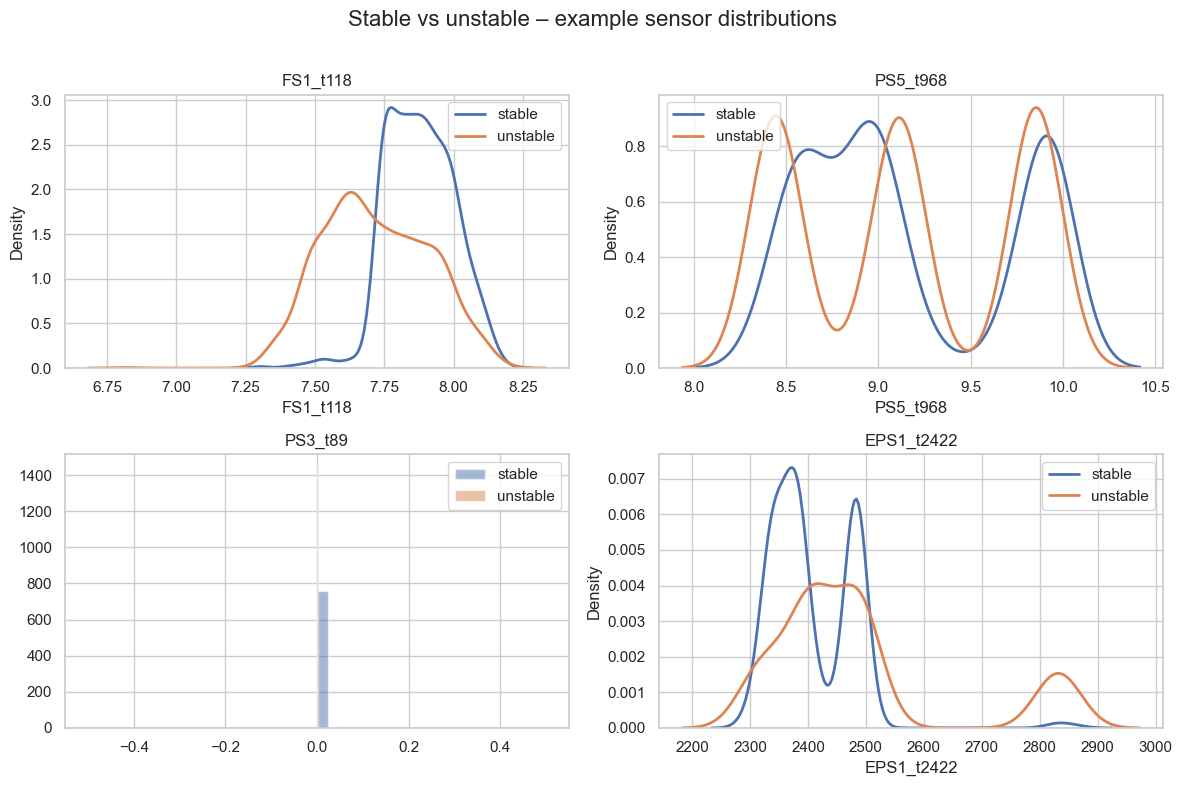

In [13]:
# === Stable vs unstable comparison (robust version) ===

# 1. Detect stability column
stability_candidates = [
    col for col in y.columns
    if "stability" in col.lower() or "stable" in col.lower()
] if isinstance(y, pd.DataFrame) else []

if isinstance(y, pd.DataFrame) and stability_candidates:
    stability_col = stability_candidates[0]
    print(f"Using stability column: {stability_col}")
else:
    print("⚠️ No stability column found — skipping stable/unstable comparison.")
    stability_col = None

# 2. Perform comparison only if stability column exists
if stability_col is not None:

    stable_mask = y[stability_col] == 1
    unstable_mask = y[stability_col] == 0

    example_sensors = pd.Series(X.columns).sample(4, random_state=42).tolist()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, col in zip(axes, example_sensors):

        stable_vals = X.loc[stable_mask, col].dropna()
        unstable_vals = X.loc[unstable_mask, col].dropna()

        # If either distribution has zero variance → use histogram
        try:
            if stable_vals.nunique() <= 1 or unstable_vals.nunique() <= 1:
                raise ValueError("Zero-variance column — using histogram fallback")

            sns.kdeplot(stable_vals, label="stable", ax=ax, linewidth=2)
            sns.kdeplot(unstable_vals, label="unstable", ax=ax, linewidth=2)

        except Exception:
            ax.hist(stable_vals, bins=40, alpha=0.5, label="stable")
            ax.hist(unstable_vals, bins=40, alpha=0.5, label="unstable")

        ax.set_title(col)
        ax.legend()

    fig.suptitle("Stable vs unstable – example sensor distributions", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    fig.savefig(IMG_DIR / "stable_vs_unstable_density.png", dpi=150)
    plt.show()


### Interpretation

- The dataset contains both stable and unstable operating regimes.
- For several sensors, unstable cycles show visibly broader or shifted distributions, reflecting transient behavior.
- This awareness is useful when designing features sensitive to stability (e.g., rolling variance around transitions)
  and when evaluating models separately on stable vs unstable subsets.


## Light temporal drift check

We inspect simple trends in example sensors across the cycle index to verify that there is no
catastrophic drift or strong regime switch that would invalidate random cross-validation.


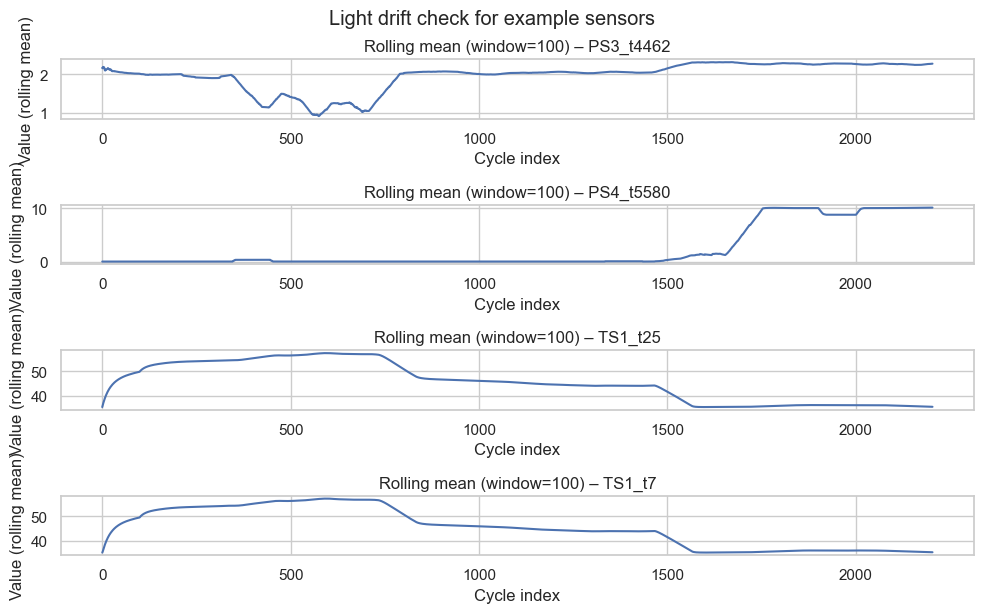

In [14]:
# === Light drift check ===

cycle_index = np.arange(len(X))

# Choose a few representative sensors
example_cols = []

# Try to prioritize sensors that look like PS or TS
for prefix in ["PS", "TS"]:
    candidates = [c for c in X.columns if c.startswith(prefix)]
    if candidates:
        example_cols.extend(pd.Series(candidates).sample(min(2, len(candidates)), random_state=42).tolist())

if not example_cols:
    example_cols = pd.Series(X.columns).sample(3, random_state=42).tolist()

plt.figure(figsize=(10, 6))
for i, col in enumerate(example_cols, start=1):
    plt.subplot(len(example_cols), 1, i)
    plt.plot(cycle_index, X[col].rolling(100, min_periods=1).mean())
    plt.title(f"Rolling mean (window=100) – {col}")
    plt.xlabel("Cycle index")
    plt.ylabel("Value (rolling mean)")
    plt.tight_layout()

plt.suptitle("Light drift check for example sensors", y=1.02)
plt.savefig(IMG_DIR / "light_drift_example_sensors.png", dpi=150)
plt.show()


## 8. Summary & next steps: What EDA Revealed and How It Guides Modeling

### What I learned from EDA
- The dataset contains **structured, multi-channel sensor data** with clear subsystem groupings
  (pressure, temperature, flow, vibration, cooler, electrical).
- Condition labels are **moderately to strongly imbalanced** (see `target_imbalance_summary.csv`), so we will:
  - rely on **F1-score / balanced metrics** instead of plain accuracy, and
  - use **stratified train/test splits** for all targets.
- Several sensors exhibit **physically meaningful spikes**, not random noise, especially in pressure and flow channels.  
  These spikes will be preserved and handled via robust scaling rather than removed as outliers.
- Group-level correlations across pressure, temperature, and vibration channels align with expected mechanical behavior
  of the hydraulic system.

### Additional EDA insights
- No missing values were found across the canonical feature set, so no imputation step is required.
- **34 constant (zero-variance) features** will be removed during feature engineering.
- Around **1.7k sparse “spike-driven” features** behave like rare event indicators and are candidates for
  failure-sensitive features.
- Sensor groups differ in temporal resolution and variance, which directly informs window sizes and aggregation
  strategies for rolling features.
- The stability label reveals clearly distinct patterns between stable and unstable cycles, and a light drift check
  over cycle index shows gradual, physically plausible changes rather than catastrophic dataset shift.

### How this shapes the next notebook (03_feature_engineering.ipynb)

EDA produced a small set of artifacts that act as a contract for the rest of the pipeline:

- Canonical label and class distribution tables:  
  `target_distributions.csv`, `target_imbalance_summary.csv`
- Descriptive statistics and missingness overview:  
  `eda_summary_stats.csv`, `eda_missing_summary.csv`
- Visual maps of group behavior, correlations, stability and drift:  
  plots stored under `images/eda/`.

In the next notebook we will:

- use the **frozen artifacts** (`X_features.parquet`, `y_labels.parquet`, `features_index.csv`),
- engineer domain-relevant rolling, delta and aggregate features per sensor group,
- drop constant features while **retaining spike-driven features**, and
- save `X_features_fe.parquet` as the single source of truth for modeling.
